In [ ]:
# 合并 SMPS 与 APS 数据，计算总的粒径分布
# 包括以下步骤：
# 1. 导入库和函数
# 2. 读取 SMPS 和 APS 数据

In [1]:
## 1. 导入库和函数
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def read_one_smps_export(path: Path, encoding="cp1252", bin_start_idx=9, bin_end_idx=112, time_format='%Y/%m/%d %H:%M:%S', scan_lines=100) -> pd.DataFrame:
    '''
    读取由 SMPS 导出的单个 TXT 文件, 返回包含时间和粒径列的 DataFrame.

    参数:
    '''
    # 1) 定位表头行 (只扫描前`scan_lines`行)
    with open(path, "r", encoding=encoding, errors="replace") as f:
        lines = []
        for _ in range(scan_lines):
            try:
                lines.append(next(f))
            except StopIteration:
                break

    header_idx = None
    for i, line in enumerate(lines):
        if 'Units' in line:
            units_idx = i
        if "Sample #" in line and "Date" in line and "Start Time" in line:
            if line.count("\t") >= 5 or line.count(",") >= 5 or line.count(";") >= 5:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError(f"{path.name}: 扫描前`scan_lines`行, 未找到表头行")
    
    header_line = lines[header_idx]
    #print(f"{path.name}的数据类型： {lines[units_idx].split('\t')[1]} ")
    if lines[units_idx].split('\t')[1].strip() != "dw/dlogDp":
        raise ValueError(f"{path.name}: 数据类型不是 dN/dlogDp，而是 {lines[units_idx].split('\t')[1]}")

    # 2) 识别分隔符
    delims = {"\t": header_line.count("\t"), ",": header_line.count(","), ";": header_line.count(";")}
    sep = max(delims, key=delims.get)

    # 3) 从表头行开始读
    df = pd.read_csv(path, sep=sep, encoding=encoding, skiprows=0, header=header_idx, engine="python")

    # 4) 生成 datetime
    t = pd.to_datetime(df["Date"].astype(str).str.strip() + " " + df["Start Time"].astype(str).str.strip(),
                       errors="coerce", # 如果需要更严格的解析, 可以去掉此行
                       format=time_format)
    bad = t.isna()
    if bad.any():
        print("解析失败行数:", bad.sum())
        print("如果行数较多，可能需要调整 time_format 参数")
        print(df.loc[bad, ["Date", "Start Time"]].head(10))
        # 需要的话：raise ValueError("Datetime parsing failed")

    df = df.loc[t.notna()].copy()
    df["__dt__"] = t.loc[t.notna()].values

    # 5) 粒径列
    BIN_COLS = list(df.columns[bin_start_idx:bin_end_idx])
    # 判断粒径列是否正确选取
    try:
        _ = np.array(BIN_COLS).astype(float)
    except ValueError:
        raise ValueError(f"{path.name}: 粒径列名不能转换为浮点数，可能选取错误：{BIN_COLS[:5]}...\n请尝试调整 bin_start_idx 和 bin_end_idx 参数")

    out = df[["__dt__"] + BIN_COLS].copy()
    out["__file__"] = path.name  # 便于追踪来源
    return out


def read_one_aps_export(path: Path, encoding="cp1252", bin_start_idx=5, bin_end_idx=56, time_format="%m/%d/%y %H:%M:%S", scan_lines=100) -> pd.DataFrame:
    '''
    读取由 APS 导出的单个 TXT 文件, 返回包含时间和粒径列的 DataFrame.

    参数:
    '''
    # 1) 定位表头行 (只扫描前`scan_lines`行)s
    with open(path, "r", encoding=encoding, errors="replace") as f:
        lines = []
        for _ in range(scan_lines):
            try:
                lines.append(next(f))
            except StopIteration:
                break

    header_idx = None
    for i, line in enumerate(lines):
        if "Sample #" in line and "Date" in line and "Start Time" in line:
            if line.count("\t") >= 5 or line.count(",") >= 5 or line.count(";") >= 5:
                header_idx = i
                break
    if header_idx is None:
        raise ValueError(f"{path.name}: 扫描前`scan_lines`({scan_lines})行, 未找到表头行")

    header_line = lines[header_idx]

    # 2) 识别分隔符
    delims = {"\t": header_line.count("\t"), ",": header_line.count(","), ";": header_line.count(";")}
    sep = max(delims, key=delims.get)

    # 3) 从表头行开始读
    df = pd.read_csv(path, sep=sep, encoding=encoding, skiprows=header_idx, header=0, engine="python")
    #print(f"`{path.name}`的数据类型: {df.iloc[0, 3]}")
    if df.iloc[0, 3] != "dN/dlogDp":
        raise ValueError(f"{path.name}: 数据类型不是 dN/dlogDp，而是 {df.iloc[0, 3]}")
    # 4) 生成 datetime
    t = pd.to_datetime(df["Date"].astype(str).str.strip() + " " + df["Start Time"].astype(str).str.strip(),
                       errors="coerce", # 如果需要更严格的解析, 可以去掉此行
                       format=time_format)
    bad = t.isna()
    if bad.any():
        print("解析失败行数:", bad.sum())
        print("如果行数较多，可能需要调整 time_format 参数")
        print(df.loc[bad, ["Date", "Start Time"]].head(10))
        # 需要的话：raise ValueError("Datetime parsing failed")
    
    df = df.loc[t.notna()].copy()
    df["__dt__"] = t.loc[t.notna()].values

    # 5) 粒径列 
    BIN_COLS = list(df.columns[bin_start_idx:bin_end_idx])# Note: 这种方法舍去了'<0.523'这一列, 缺失部分由 SMPS 补全.
    # 判断粒径列是否正确选取
    try:
        _ = np.array(BIN_COLS).astype(float)
    except ValueError:
        raise ValueError(f"{path.name}: 粒径列名不能转换为浮点数，可能选取错误：{BIN_COLS[:5]}...\n请尝试调整 bin_start_idx 和 bin_end_idx 参数")

    out = df[["__dt__"] + BIN_COLS].copy()
    out["__file__"] = path.name  # 便于追踪来源
    return out

def dups_check(df: pd.DataFrame, time_col="__dt__") -> pd.DataFrame:
    '''
    检查 DataFrame 中的重复时间戳, 若有重复, 则尝试去重.
    '''
    n_dups = df.duplicated(subset=time_col).sum()
    if n_dups > 0:
        print(f"⚠️ 数据中存在 {n_dups} 行重复时间戳，尝试去重:")
        n_before = len(df)
        df = df.drop_duplicates(subset=time_col, keep="last").reset_index(drop=True)# 去重策略：同一时间点保留“最后出现的那条”（通常后导出的文件更完整）
        print("\n=== 去重结果 ===")
        print("合并前总行数 =", n_before)
        print("重复时间点数 =", int(n_dups))
        print("去重后总行数 =", len(df))
    else:
        print("✅ 数据中没有重复时间戳")

def diff_check(df: pd.DataFrame, time_col="__dt__") -> None:
    '''
    计算采样间隔, 并打印基本分布情况, 以帮助诊断数据质量问题.
    '''
    dt_diff = df[time_col].diff().dropna().dt.total_seconds()
    print("采样间隔(秒)：中位数 =", float(dt_diff.median()),
        "最小 =", float(dt_diff.min()),
        "最大 =", float(dt_diff.max()))

In [2]:
## 2. 读取 SMPS 和 APS 数据
### 1) 读取 APS 数据
aps_dir = Path(r"D:\Coding\Data\Lanzhou_aerosol\APS_dNdlogDp")
aps_data = list(aps_dir.glob('*.TXT'))
print("APS 文件数 =", len(aps_data))

aps_all = []
for p in aps_data:
    try:
        one = read_one_aps_export(p)
        aps_all.append(one)
        print(f"✅ {p.name}: {len(one)} 行, 时间 {one['__dt__'].min()} ~ {one['__dt__'].max()}")
    except Exception as e:
        print(f"❌ {p.name}: 读取失败 -> {repr(e)}")

aps_df = pd.concat(aps_all, ignore_index=True)
aps_df = aps_df.sort_values("__dt__").reset_index(drop=True)

dups_check(aps_df)# 检查 APS 数据中的重复时间戳
diff_check(aps_df)# 检查 APS 数据中的采样间隔

print("\n------------------------------------------------------------\n")

### 2) 读取 SMPS 数据
smps_dir = Path(r"D:\Coding\Data\Lanzhou_aerosol\SMPS_dNdlogDp")
smps_data = list(smps_dir.glob('*.TXT'))
print("SMPS 文件数 =", len(smps_data))

smps_all = []
for p in smps_data:
    try:
        one = read_one_smps_export(p)
        smps_all.append(one)
        print(f"✅ {p.name}: {len(one)} 行, 时间 {one['__dt__'].min()} ~ {one['__dt__'].max()}")
    except Exception as e:
        print(f"❌ {p.name}: 读取失败 -> {repr(e)}")

smps_df = pd.concat(smps_all, ignore_index=True)
smps_df = smps_df.sort_values("__dt__").reset_index(drop=True)

dups_check(smps_df)# 检查 SMPS 数据中的重复时间戳
diff_check(smps_df)# 检查 SMPS 数据中的采样间隔

APS 文件数 = 11
✅ 20241206.TXT: 123 行, 时间 2024-12-06 13:42:24 ~ 2024-12-06 23:57:34
✅ 20241208-1230.TXT: 6493 行, 时间 2024-12-08 00:04:48 ~ 2024-12-30 18:07:44
✅ 20241230.TXT: 46 行, 时间 2024-12-30 18:33:41 ~ 2024-12-30 22:21:08
✅ 20241231-20250119.TXT: 5445 行, 时间 2024-12-31 11:01:15 ~ 2025-01-19 12:55:29
✅ 20250119.TXT: 96 行, 时间 2025-01-19 14:20:32 ~ 2025-01-19 22:20:23
✅ 20250120-0212.TXT: 6598 行, 时间 2025-01-20 19:24:36 ~ 2025-02-12 22:19:20
✅ 20250215-0221.TXT: 1827 行, 时间 2025-02-15 12:50:21 ~ 2025-02-21 22:22:52
✅ 20250222-0313.TXT: 5360 行, 时间 2025-02-22 20:23:25 ~ 2025-03-13 11:31:28
✅ 20250313-0530.TXT: 22296 行, 时间 2025-03-13 11:52:35 ~ 2025-05-30 15:06:08
✅ 20250911-0917.TXT: 4382 行, 时间 2025-09-11 16:20:23 ~ 2025-09-17 18:22:23
✅ 20250917-0929.TXT: 8753 行, 时间 2025-09-17 18:31:40 ~ 2025-09-29 22:15:40
✅ 数据中没有重复时间戳
采样间隔(秒)：中位数 = 302.0 最小 = 119.0 最大 = 8990055.0

------------------------------------------------------------

SMPS 文件数 = 33
✅ 20241205-1215.TXT: 7440 行, 时间 2024-12-05 13:17:56 

In [3]:
# ===== 剔除异常高浓度时间段 =====
smps_bad_periods = [
    ("2024-12-14 23:00", "2024-12-16 00:00"),
    ("2024-12-22 19:00", "2024-12-23 12:00"),
    ("2025-03-10 04:00", "2025-03-10 14:00"),
    ("2025-03-25 21:00", "2025-03-25 23:00"),
    ("2025-06-19 00:00", "2025-06-20 00:00"),
    ("2025-07-23 14:50", "2025-07-23 15:00"),
    ("2025-08-11 17:49", "2025-08-11 17:50"),
    ("2025-08-14 23:00", "2025-08-15 16:00"),
    ("2025-10-16 23:00", "2025-10-19 00:00"),
]
for start_str, end_str in smps_bad_periods:
    start = pd.to_datetime(start_str)
    end = pd.to_datetime(end_str)
    mask = (smps_df["__dt__"] >= start) & (smps_df["__dt__"] <= end)
    n_bad = mask.sum()
    if n_bad > 0:
        print(f"剔除 SMPS 数据中 {start} ~ {end} 的 {n_bad} 行")
        smps_df = smps_df.loc[~mask].reset_index(drop=True)

剔除 SMPS 数据中 2024-12-14 23:00:00 ~ 2024-12-16 00:00:00 的 749 行
剔除 SMPS 数据中 2024-12-22 19:00:00 ~ 2024-12-23 12:00:00 的 510 行
剔除 SMPS 数据中 2025-03-10 04:00:00 ~ 2025-03-10 14:00:00 的 300 行
剔除 SMPS 数据中 2025-03-25 21:00:00 ~ 2025-03-25 23:00:00 的 52 行
剔除 SMPS 数据中 2025-06-19 00:00:00 ~ 2025-06-20 00:00:00 的 100 行
剔除 SMPS 数据中 2025-07-23 14:50:00 ~ 2025-07-23 15:00:00 的 5 行
剔除 SMPS 数据中 2025-08-14 23:00:00 ~ 2025-08-15 16:00:00 的 510 行
剔除 SMPS 数据中 2025-10-16 23:00:00 ~ 2025-10-19 00:00:00 的 1184 行


In [4]:
## 统一时间轴: 重采样并取平均值

# 定义重采样的时间频率，建议设为 10min (与 INP 采样时间一致)
resample_freq = '10min'

# 设置时间为索引
smps_df.set_index("__dt__", inplace=True)
aps_df.set_index("__dt__", inplace=True)

# 移除不需要合并的辅助列
if "__file__" in smps_df.columns:
    smps_df = smps_df.drop(columns=["__file__"])
if "__file__" in aps_df.columns:
    aps_df = aps_df.drop(columns=["__file__"])

print(f"正在按 {resample_freq} 进行重采样并取平均值...")

# 对 SMPS 和 APS 分别重采样
# closed='left', label='left' 表示时间戳代表该窗口的起始时间
smps_resampled = smps_df.resample(resample_freq, closed='left', label='left').mean()
aps_resampled = aps_df.resample(resample_freq, closed='left', label='left').mean()

print(f"SMPS 重采样后行数: {len(smps_resampled)}")
print(f"APS 重采样后行数: {len(aps_resampled)}")

# 检查一下是否有全空行（由于原始数据中有大段空白时间段导致的）
smps_resampled.dropna(how='all', inplace=True)
aps_resampled.dropna(how='all', inplace=True)

print(f"剔除全空行后 - SMPS: {len(smps_resampled)}, APS: {len(aps_resampled)}")

正在按 10min 进行重采样并取平均值...
SMPS 重采样后行数: 45419
APS 重采样后行数: 42820
剔除全空行后 - SMPS: 36564, APS: 26976


In [5]:
## 转换粒径列名为数值并排序

def clean_and_sort_columns(df):
    # 找出所有可以转换为数字的列（排除非粒径列，如果有的话）
    # 在重采样后，现在的列应该全都是粒径值了
    new_cols = []
    for col in df.columns:
        try:
            new_cols.append(float(col))
        except ValueError:
            # 如果有不能转成数字的列，保持原样（虽然通常不应该有）
            new_cols.append(col)
    
    df.columns = new_cols
    # 按列名（粒径大小）从小到大排序
    df = df.reindex(sorted(df.columns), axis=1)
    return df

smps_resampled = clean_and_sort_columns(smps_resampled)
print(f"SMPS 粒径范围: {min(smps_resampled.columns)} ~ {max(smps_resampled.columns)} nm")

# 注意：APS 的单位通常是微米(μm)，如果你的 SMPS 是纳米(nm)，
# 我们需要统一单位。通常统一为纳米 (nm)。
# 假设 SMPS 列名是 10~1000 左右，APS 列名是 0.5~20 左右。
# 我们检查一下：
aps_cols_sample = float(aps_resampled.columns[0])
if aps_cols_sample < 20: # 如果数值很小，说明是微米
    print("检测到 APS 单位为微米 (μm)，正在转换为纳米 (nm)...")
    aps_resampled.columns = [float(c) * 1000 for c in aps_resampled.columns]

aps_resampled = clean_and_sort_columns(aps_resampled)

print(f"APS 粒径范围: {min(aps_resampled.columns)} ~ {max(aps_resampled.columns)} nm")

SMPS 粒径范围: 13.1 ~ 532.8 nm
检测到 APS 单位为微米 (μm)，正在转换为纳米 (nm)...
APS 粒径范围: 542.0 ~ 19810.0 nm


In [6]:
## 将 APS 的空气动力学直径 Da 转换为电迁移率直径 Dm

def convert_da_to_dm(da, rho_eff=1.5, rho_0=1.0, x=1.0, slip_correction=False):
    """
    将空气动力学直径 Da 转换为电迁移率直径 Dm

    da: APS 测得的空气动力学直径 (数组或标量，单位 um)

    rho_eff: 假设的有效密度 (g/cm3)

    rho_0: 标准密度 (1.0 g/cm3)

    x: 形状修正因子 (shape factor = 1.0, 表示球形粒子)
    """
    if slip_correction:
        print ('At sizes of the APS–SMPS overlap size range the slip correction can be neglected;'
        ' for the particle density of 2 g cm−3, the shape factor of 1,'
        ' and the physical diameter of 500 nm the error in calculating the aerodynamic diameter is 4%.' \
        ' At lower particle densities and larger shape factors the error will be even smaller.')

        print('\nCunningham 滑移修正可忽略不计, 因此直接使用简单的 Da-Dm 关系进行转换')
        dm = da * np.sqrt(rho_0 * x / rho_eff)
    else:
        dm = da * np.sqrt(rho_0 * x / rho_eff)
    
    return dm

# APS 测得的粒径序列(单位 μm)
aps_da = aps_resampled.columns.values

# Da 转 Dm
rho_p = 1.5 # 假设气溶胶粒子的有效密度为 1.5 g/cm3
aps_dm = convert_da_to_dm(aps_da, rho_eff=rho_p)

# 创建一个新的 DataFrame 存储转换后的 APS 数据
aps_dm_resampled = aps_resampled.copy()
aps_dm_resampled.columns = aps_dm # 将列名替换为 Dm

# 输出结果
print(f"假设有效密度为: {rho_p} g/cm3")
print("-" * 40)
print(f"{'Aerodynamic Da (um)':<20} | {'Mobility Dm (um)':<20}")
print("-" * 40)
for a, m in zip(aps_da, aps_dm):
    print(f"{a:<20.4f} | {m:<20.4f}")

# 去除 APS 中大于 2500 nm 的粒径（为保证气溶胶数据与 INP 数据的一致性）
aps_dm_resampled = aps_dm_resampled.loc[:, aps_dm_resampled.columns <= 2500]
print(f"\n转换后 APS 粒径范围(已舍去 > 2500 nm): {min(aps_dm_resampled.columns)} ~ {max(aps_dm_resampled.columns)} nm")


假设有效密度为: 1.5 g/cm3
----------------------------------------
Aerodynamic Da (um)  | Mobility Dm (um)    
----------------------------------------
542.0000             | 442.5411            
583.0000             | 476.0175            
626.0000             | 511.1269            
673.0000             | 549.5022            
723.0000             | 590.3270            
777.0000             | 634.4178            
835.0000             | 681.7746            
898.0000             | 733.2139            
965.0000             | 787.9192            
1037.0000            | 846.7070            
1114.0000            | 909.5772            
1197.0000            | 977.3464            
1286.0000            | 1050.0146           
1382.0000            | 1128.3983           
1486.0000            | 1213.3139           
1596.0000            | 1303.1285           
1715.0000            | 1400.2916           
1843.0000            | 1504.8032           
1981.0000            | 1617.4797           
2129.0000          

In [46]:
aps_dm_resampled.head()

,442.541147,476.017507,511.126860,549.502199,590.327028,634.417843,681.774645,733.213930,787.919201,846.706954,...,1303.128543,1400.291636,1504.803199,1617.479727,1738.321221,1868.144177,2006.948596,2157.183967,2318.033793,2491.131068
__dt__,,,,,,,,,,,,,,,,,,,,,
2024-12-06 13:40:00,13.47180,32.8705,73.0549,132.747,192.176,203.188,154.823,92.6590,52.5325,29.9681,...,4.75174,4.39215,3.77571,3.26843,2.87031,2.73546,2.22818,1.99060,1.77227,1.47047
2024-12-06 13:45:00,14.01760,33.2622,73.6520,134.128,192.947,198.514,151.459,89.9300,50.4648,28.7481,...,4.78385,4.10962,3.59591,3.06295,2.92168,2.60062,2.06123,1.92638,1.66953,1.57321
2024-12-06 13:50:00,11.93720,28.7545,66.4795,120.341,174.697,183.507,137.614,81.5631,44.4417,26.1731,...,4.12888,3.62160,3.49960,3.21064,2.90242,2.74188,2.06123,1.84933,1.49616,1.47047
2024-12-06 13:55:00,9.59981,23.7138,55.3129,102.092,149.121,154.201,117.124,69.4397,38.7781,23.2065,...,3.90414,3.54454,3.17211,2.93452,2.72904,2.15755,1.95849,1.88786,1.41268,1.30352
2024-12-06 14:00:00,10.85200,26.7061,57.3869,108.160,155.690,162.079,120.598,70.8652,39.1569,23.3413,...,3.92340,3.64728,3.12716,2.68409,2.56851,2.39514,1.90712,1.77227,1.40626,1.28426


In [32]:
smps_resampled.head()

,13.1,13.6,14.1,14.6,15.1,15.7,16.3,16.8,17.5,18.1,...,385.4,399.5,414.2,429.4,445.1,461.4,478.3,495.8,514.0,532.8
__dt__,,,,,,,,,,,,,,,,,,,,,
2024-12-05 13:15:00,NaN,3669.679500,3864.048500,3652.227500,4393.650000,4563.684500,5006.464000,4517.117500,5909.645000,5887.756000,...,1231.470000,1012.318000,1002.926500,651.882500,627.806500,431.329500,516.160500,232.206500,118.2720,160.7025
2024-12-05 13:20:00,NaN,1078.696000,821.598000,1460.614500,2764.808500,2394.933500,2952.438000,3275.222000,3523.535000,4526.824000,...,1320.866000,1168.549000,1073.112500,861.566500,611.313500,565.635500,308.034000,309.950000,257.3015,189.7125
2024-12-05 13:25:00,NaN,414.305333,1034.999000,926.747667,1486.567667,2019.585667,2176.904000,2675.409333,3210.476333,3152.884667,...,1391.429667,1185.561667,899.850333,653.892333,503.751667,492.052333,362.400000,337.702333,300.9110,301.1270
2024-12-05 13:30:00,NaN,673.129000,1101.242500,1176.244000,1988.835500,2586.846500,2608.127500,2829.408000,3738.428000,3986.008500,...,1326.484000,894.295500,854.384000,503.353000,699.110500,432.637500,349.574500,118.199000,220.2255,142.7985
2024-12-05 13:35:00,NaN,767.457667,534.958667,1220.740000,1294.021333,2030.165333,2756.286667,2723.729000,3465.985000,3605.511000,...,920.992667,943.733667,773.862667,510.977667,612.622667,588.216667,375.978333,163.340000,213.1730,230.7730


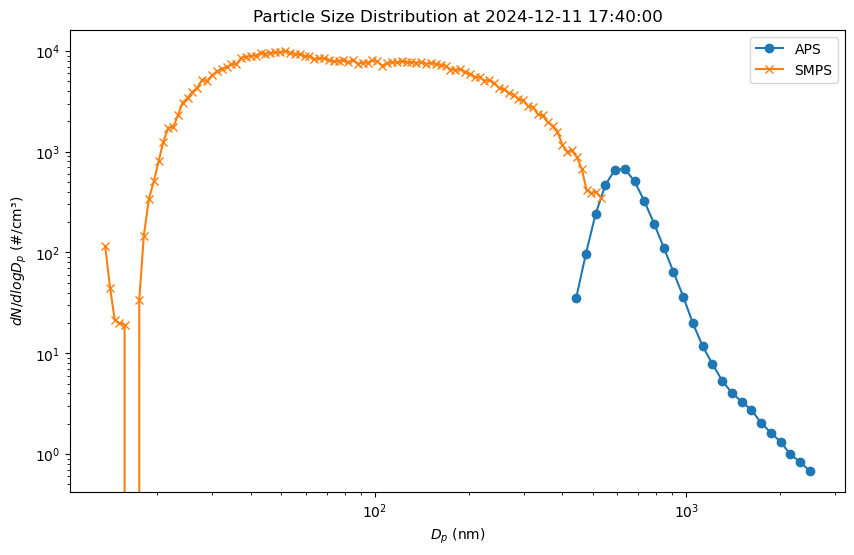

In [80]:
target_time = pd.to_datetime("2024-12-06 13:40:00")
target_time = aps_dm_resampled.index[600]
smps_resampled.loc[target_time]
aps_dm_resampled.loc[target_time]

plt.figure(figsize=(10, 6))
plt.plot(aps_dm_resampled.columns, aps_dm_resampled.loc[target_time], marker='o', label='APS')
plt.plot(smps_resampled.columns, smps_resampled.loc[target_time], marker='x', label='SMPS')
plt.xscale('log')
plt.yscale('log')
plt.xlabel("$D_p$ (nm)")
plt.ylabel("$dN/dlogD_p$ (#/cm³)")
plt.title(f"Particle Size Distribution at {target_time}")
plt.legend()
plt.show()

In [7]:
def merge_smps_aps(smps_df, aps_df):
    """
    拼接 SMPS 和转换后的 APS 数据, 考虑到 APS 的前几个通道效率较低, 因此两仪器的重叠部分以 SMPS 为准.

    确保两者拥有相同的时间索引 (index), 并且列名（粒径通道）从小到大排序, 形成一个连续的粒径谱图.
    """
    # 找到 SMPS 的最大的粒径
    smps_max_Dp = smps_df.columns.max() # 应该是 532.8 nm

    # 仅保留 APS 大于 SMPS 最大粒径(通道)的部分
    aps_dm_filtered = aps_df.loc[:, aps_df.columns > smps_max_Dp]

    print(f"裁切后, APS 保留的最小粒径为: {aps_dm_filtered.columns.min():.2f} nm")
    
    # 按时间 (index) 拼接两个 DataFrame
    combined_df = pd.concat([smps_df, aps_dm_filtered], axis=1, join='inner') # 只保留两者共有的时间点
    
    # 4. 对列名（粒径通道）进行升序排序，确保形成一个连续的谱图
    combined_df = combined_df.reindex(sorted(combined_df.columns), axis=1)
    
    return combined_df

# 执行拼接
final_psd_df = merge_smps_aps(smps_resampled, aps_dm_resampled)

# 检查结果
print(f"最终合并数据的维度 (行, 列): {final_psd_df.shape}")
print(f"最终合并数据的粒径范围: {final_psd_df.columns.min():.2f} nm ~ {final_psd_df.columns.max():.2f} nm")

final_psd_df.head()

裁切后, APS 保留的最小粒径为: 549.50 nm
最终合并数据的维度 (行, 列): (22364, 126)
最终合并数据的粒径范围: 13.10 nm ~ 2491.13 nm


,13.100000,13.600000,14.100000,14.600000,15.100000,15.700000,16.300000,16.800000,17.500000,18.100000,...,1303.128543,1400.291636,1504.803199,1617.479727,1738.321221,1868.144177,2006.948596,2157.183967,2318.033793,2491.131068
__dt__,,,,,,,,,,,,,,,,,,,,,
2024-12-06 13:40:00,NaN,284.9306,146.1352,139.3162,189.9656,109.1666,345.8240,530.7916,1070.5632,1225.6524,...,4.767795,4.250885,3.685810,3.165690,2.895995,2.668040,2.144705,1.958490,1.720900,1.521840
2024-12-06 13:50:00,NaN,219.1956,125.2564,119.4178,151.9780,236.5516,310.6156,541.9190,939.6136,771.7370,...,4.016510,3.583070,3.335855,3.072580,2.815730,2.449715,2.009860,1.868595,1.454420,1.386995
2024-12-06 14:00:00,NaN,87.6768,146.1338,99.5116,113.9806,90.1970,328.7940,720.8830,1257.3626,1278.3934,...,3.961930,3.480330,3.197795,2.831780,2.552455,2.363030,1.929595,1.740165,1.534685,1.245730
2024-12-06 14:10:00,NaN,175.3568,146.1246,159.2276,170.9682,254.7406,415.1790,787.0262,1265.2530,1598.2900,...,3.843135,3.326225,2.867100,2.754725,2.199285,2.208920,1.887855,1.675950,1.480105,1.300310
2024-12-06 14:20:00,NaN,131.5200,83.4998,79.6094,172.1400,217.2336,453.1576,801.3784,1193.2574,1768.0374,...,3.631230,3.313380,2.902415,2.587770,2.356610,2.208920,1.801170,1.640635,1.422315,1.184725


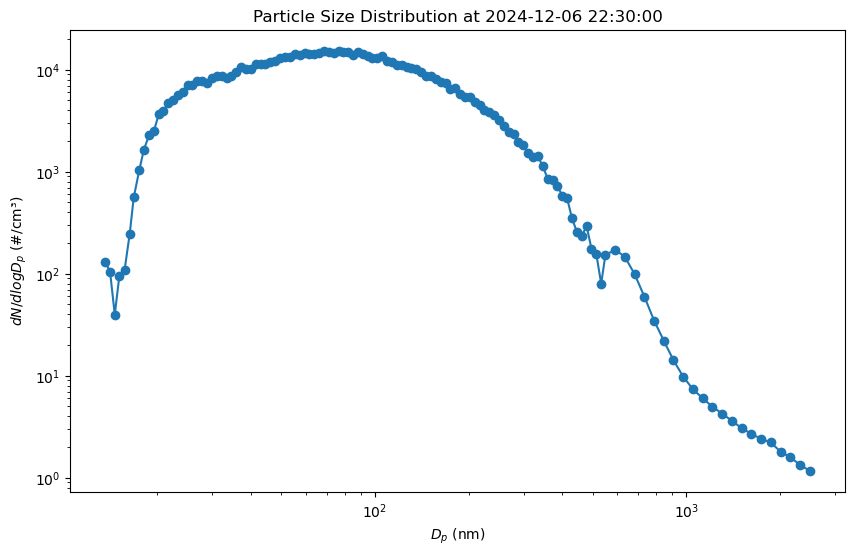

In [ ]:
# 画出某一个时间点的完整谱图（以对数粒径为 x 轴）

target_time = final_psd_df.index[200] # 选择一个时间点
plt.figure(figsize=(10, 6))
plt.plot(final_psd_df.columns, final_psd_df.loc[target_time], marker='o')
plt.xscale('log')
plt.yscale('log')

plt.xlabel("$D_p$ (nm)")
plt.ylabel("$dN/dlogD_p$ (#/cm³)")
plt.title(f"Particle Size Distribution at {target_time}")
plt.show()

In [8]:
def calculate_surface_area(df):
    """
    计算气溶胶总表面积浓度
    - 参数:
    df: pd.DataFrame, 其中, index为时间, columns为粒径通道(nm), value为 dN/dlogDp (#/cm^3)
    - 返回:
    pd.Series: 总表面积浓度 (单位: μm^2/cm^3)
    """
    
    # 1. 提取粒径通道(Dp)，将列名从字符串转为浮点数
    dp_nm = np.array(df.columns.astype(float))
    
    # 2. 将粒径单位从 nm 转换为 μm (为了得到常用的 μm^2/cm^3 单位)
    dp_um = dp_nm / 1000.0
    
    # 3. 计算每个通道的 dlogDp
    # 大多数仪器(如SMPS)的粒径在对数坐标下是等间距的
    # 我们通过计算相邻通道 log10(Dp) 的差值来获取
    log_dp = np.log10(dp_nm)
    
    # 计算相邻间距
    delta_log_dp = np.zeros_like(log_dp)
    # 对于中间部分，使用相邻通道的差值
    delta_log_dp[:-1] = np.diff(log_dp)
    # 最后一个通道的间距假设与倒数第二个相同
    delta_log_dp[-1] = delta_log_dp[-2]
    
    # 4. 计算每个通道的表面积贡献 dS
    # 公式: dS = pi * Dp^2 * (dN/dlogDp) * delta_log_dp
    # 注意: dp_um 是矢量, df 是矩阵, 利用广播机制计算
    
    # 计算每一项: pi * Dp^2 * dlogDp
    multiplier = np.pi * (dp_um**2) * delta_log_dp
    
    # 逐行相乘并求和
    # df.values 的形状是 (时间, 粒径), multiplier 的形状是 (粒径,)
    #surface_area_conc = (df.values * multiplier).sum(axis=1)
    surface_area_conc = df.multiply(multiplier, axis=1).sum(axis=1, min_count=1)
    
    # 5. 返回结果，保持与原数据相同的索引
    return pd.Series(surface_area_conc, index=df.index, name='Total_Surface_Area_um2_cm3')

# 计算
total_s = calculate_surface_area(final_psd_df)

print("\n计算得到的总表面积浓度 (μm^2/cm^3):")
print(total_s.dropna())


计算得到的总表面积浓度 (μm^2/cm^3):
__dt__
2024-12-06 13:40:00    475.915821
2024-12-06 13:50:00    433.722677
2024-12-06 14:00:00    394.965604
2024-12-06 14:10:00    369.544082
2024-12-06 14:20:00    380.647815
                          ...    
2025-09-29 21:30:00    350.224085
2025-09-29 21:40:00    364.416849
2025-09-29 21:50:00    404.945090
2025-09-29 22:00:00    531.983207
2025-09-29 22:10:00    529.448685
Name: Total_Surface_Area_um2_cm3, Length: 22364, dtype: float64


In [9]:
# 找到最大表面积浓度的时间点
max_time = total_s.idxmax()
print(f"\n最大表面积浓度的时间点: {max_time}, 值: {total_s.loc[max_time]:.2f} μm^2/cm^3")


最大表面积浓度的时间点: 2025-02-12 22:00:00, 值: 3970.29 μm^2/cm^3


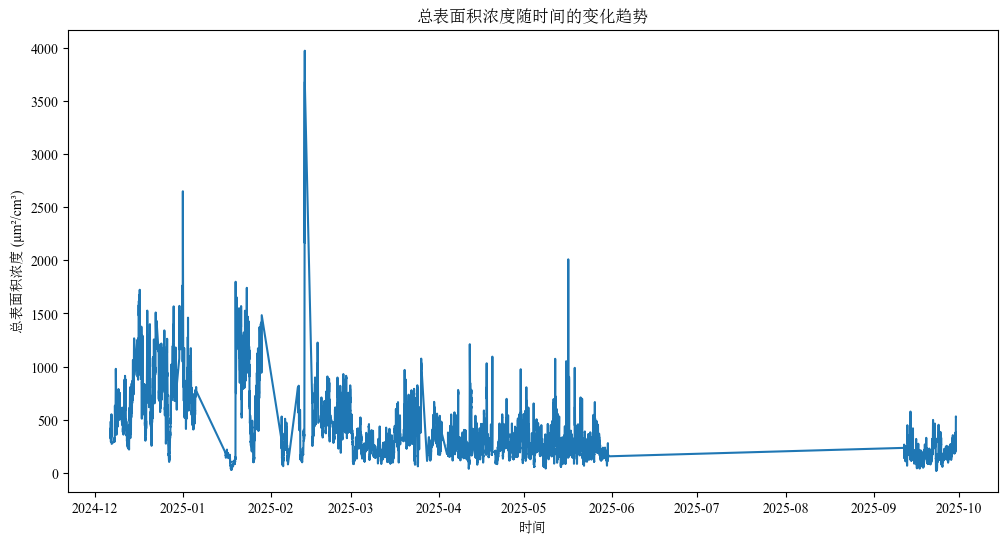

In [10]:
# 画出总表面积浓度随时间的变化趋势
plt.rcParams['font.family'] = ["Times New Roman", 'SimSun']
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(total_s.index, total_s.values)
#ax.set_xlim(pd.Timestamp('2025-03-25 21:00'), pd.Timestamp('2025-03-29 00:00'))
ax.set_xlabel("时间")
ax.set_ylabel("总表面积浓度 (μm²/cm³)")
ax.set_title("总表面积浓度随时间的变化趋势")
plt.show()

In [95]:
# 保存最终的合并数据到 CSV 文件
output_path = Path(r"D:\Coding\Data\Lanzhou_aerosol\final_psd.csv")
final_psd_df.to_csv(output_path)

In [9]:
# 将计算得到的总表面积浓度与 INP 数据合并

# 1. 准备工作：确保时间格式正确
df_inp = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\processed\N_INP(202409-202509)v2.3.csv")
df_inp['Date'] = pd.to_datetime(df_inp['Date'])

# 将 Series 转换为 DataFrame，并确保索引是 datetime 类型
sa_df = total_s.to_frame().reset_index()
sa_df.columns = ['Time_A', 'Total_Surface_Area(μm2/cm3)'] # 重命名方便识别
sa_df['Time_A'] = pd.to_datetime(sa_df['Time_A'])

# 2. 关键步骤：必须进行排序
# pd.merge_asof 要求两个数据集必须按时间顺序排列
df_inp = df_inp.sort_values('Date')
sa_df = sa_df.sort_values('Time_A')

# 3. 执行模糊匹配合并
result = pd.merge_asof(
    df_inp, 
    sa_df, 
    left_on='Date',          # 左表匹配键
    right_on='Time_A',      # 右表匹配键
    direction='nearest',     # 搜索方向：最近的时间点
    tolerance=pd.Timedelta('1h') # 容差限制：1小时
)

# 4. 可选：清理辅助列
# 如果匹配失败（超过1小时），Total_Surface_Area 列会自动填充为 NaN
# Time_A 列可以用来检查实际匹配到了哪个时间点，如果不需要可以删掉
# result = result.drop(columns=['Time_A'])

In [11]:
print(result.shape)
result.head()

(2678, 10)


,Date,N_inp_net(#/L),T_inp(°C),SS_w,SS_i,Total_Sampling_Volume(L),season,T_a(°C),Time_A,Total_Surface_Area(μm2/cm3)
0,2024-09-24 14:41:43.068586,14.050137,-29.797332,5.761454,41.444960,6.149300,Autumn,-30,NaT,NaN
1,2024-09-26 14:13:58.060174,31.918336,-29.789597,5.983611,41.736518,6.291500,Autumn,-30,NaT,NaN
2,2024-09-26 14:26:14.060563,27.829487,-29.781749,5.968580,41.693702,6.266200,Autumn,-30,NaT,NaN
3,2024-09-26 16:07:50.060424,15.449528,-29.756955,4.246887,39.362124,6.032083,Autumn,-30,NaT,NaN
4,2024-09-26 16:20:06.060029,6.189200,-29.747240,4.200907,39.280730,6.042150,Autumn,-30,NaT,NaN


In [14]:
result = result.dropna(subset=['Total_Surface_Area(μm2/cm3)'])
print(f"合并后数据的维度: {result.shape}")
result['n_s'] = result['N_inp_net(#/L)'] / result['Total_Surface_Area(μm2/cm3)'] * 1e3 * 1e12

合并后数据的维度: (1641, 11)


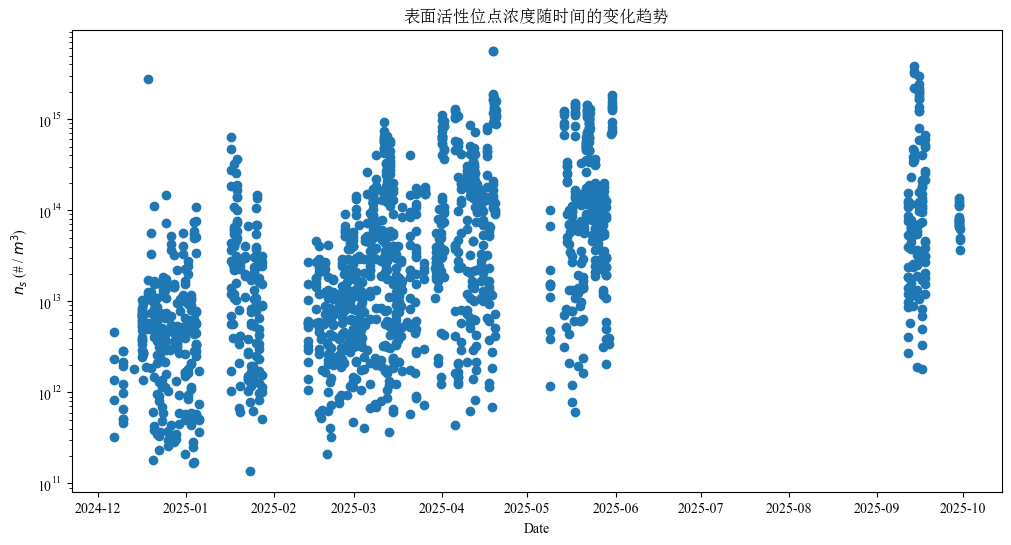

In [17]:
# 画出表面活性位点n_s随时间的变化趋势
plt.rcParams['font.family'] = ["Times New Roman", 'SimSun']
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(result['Date'], result['n_s'])
#ax.set_xlim(pd.Timestamp('2025-03-25 21:00'), pd.Timestamp('2025-03-29 00:00'))
ax.set_xlabel("Date")
ax.set_ylabel("$n_s$ (# / $m^3$)")
ax.set_yscale('log')
ax.set_title("表面活性位点浓度随时间的变化趋势")
plt.show()